# Correlating LDA axes with trial-level behavior

In [1]:
prefix = '/home/ines/repositories/'
prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [2]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# --Machine learning and statistics

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
import pickle
import scipy.cluster.hierarchy as sch
from scipy import stats
from sklearn.metrics import f1_score

# Get my functions
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//3_postprocess_results/'
os.chdir(functions_path)
from plotting_functions import create_grouped_gradient_palette

from one.api import ONE
one = ONE(mode='remote')

In [3]:
data_path = prefix + 'representation_learning_variability/paper-individuality/1_segmentation/'
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# states_file = pd.read_parquet(data_path+'states_trial_type_09-29-2025')
data_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/segmentation/'

filename = str(data_path + 'all_sequences_09-29-2025')
filename = str(data_path + 'all_sequences_26-03-2026')
all_sequences = pd.read_parquet(filename)

In [ ]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
lda_df = pd.read_pickle(data_path+'extended_mouse_LDA_5_bins_cut')

## Trial data

In [5]:
# Save data
data_path = prefix + 'representation_learning_variability/paper-individuality/2_pre-trial/'
filename = "syllable_prob.pqt"
trials_file = pd.read_parquet(data_path+filename, engine='pyarrow')

In [6]:
path = prefix + 'representation_learning_variability/paper-individuality/learning_prediction/'
path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/training_data/'
training_time = pd.read_parquet(path+'training_time_27-04-2026')

# Correlate with training time

In [7]:
var_name = 'training_days'
learning_df = lda_df.merge(training_time, on='mouse_name')
learning_df['log_training'] = np.log(learning_df[var_name])

Text(0, 0.5, 'LDA component 2')

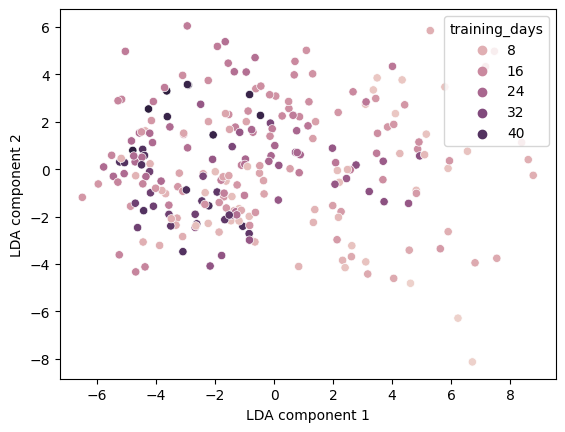

In [8]:
sns.scatterplot(x=0, y=1, hue=var_name, data=learning_df)
plt.xlabel('LDA component 1')
plt.ylabel('LDA component 2')

PearsonRResult(statistic=-0.4849150370394502, pvalue=0.00015217194484439052)


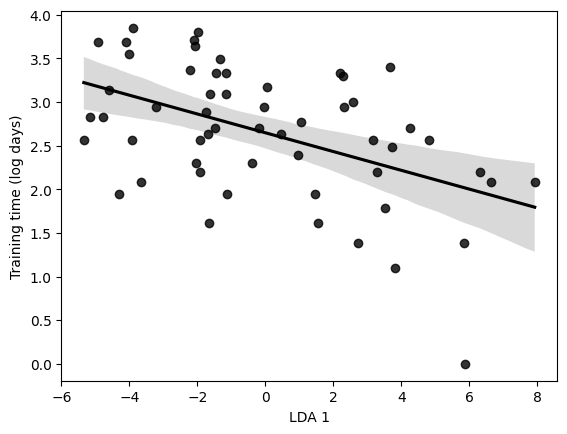

In [9]:
component = 0
group_df = learning_df.groupby(['mouse_name', var_name])[component].mean().reset_index()

sns.regplot(x=np.array(group_df[component]).astype(float), y=np.log(group_df[var_name]).astype(float), color='black', ci=95) 
plt.xlabel('LDA 1')
plt.ylabel('Training time (log days)')
plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'training_time_corre_lda1.svg', format='svg', bbox_inches='tight')

res = stats.pearsonr(np.array(group_df[component]).astype(float), np.log(group_df[var_name]).astype(float))
print(res)

PearsonRResult(statistic=-0.4256355480858071, pvalue=2.2298310010426177e-12)


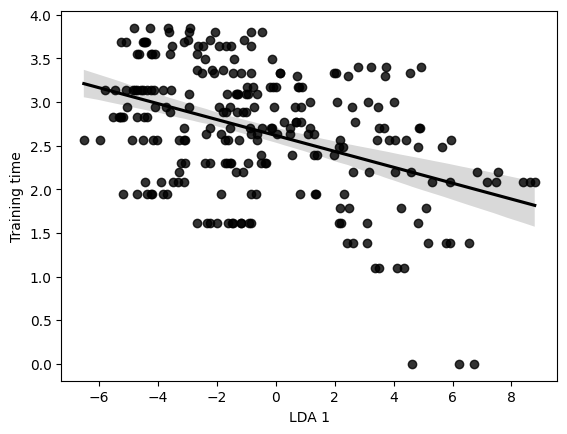

In [10]:
component = 0
group_df = learning_df.groupby(['mouse_name', var_name])[component].mean().reset_index()

sns.regplot(x=np.array(learning_df[component]).astype(float), y=np.log(learning_df[var_name]).astype(float), 
            color='black',ci=95) 
plt.xlabel('LDA 1')
plt.ylabel('Training time')

res = stats.pearsonr(np.array(learning_df[component]).astype(float), np.log(learning_df[var_name]).astype(float))
print(res)

# Correlate with trial features

In [21]:
trials_file.loc[trials_file['choice']=='left', 'choice'] = 0
trials_file.loc[trials_file['choice']=='right', 'choice'] = 1
# Compute block bias shift
# For zero contrast, difference in choice across blocks
block_df = trials_file.groupby(['session', 'block', 'contrast'])['choice'].mean().reset_index()
# block_df = states_file.groupby(['session', 'block'])['choice'].mean().reset_index()
bias_shift = block_df.loc[block_df['contrast']==0].pivot(index=['session'], columns=['block'], values=['choice'])
# bias_shift = block_df.pivot(index=['session'], columns=['block'], values=['choice'])
bias_shift['bias_shift'] = bias_shift[('choice', 0.8)] - bias_shift[('choice', 0.2)] 
bias_df = pd.DataFrame(np.array(bias_shift.reset_index()))
bias_df = bias_df.rename(columns={0:'session', 1:'0.2', 2:'0.5', 3:'0.8', 4:'bias'})
b = trials_file.groupby(['session', 'mouse_name'])[['correct', 'choice']].mean().reset_index()
# merged = trials_file.merge(b, on=['session', 'mouse_name'])
merged = b.merge(bias_df[['session', 'bias']], on='session')

In [23]:
df = merged.merge(lda_df, on=['mouse_name', 'session'])

Text(0, 0.5, 'LDA component 2')

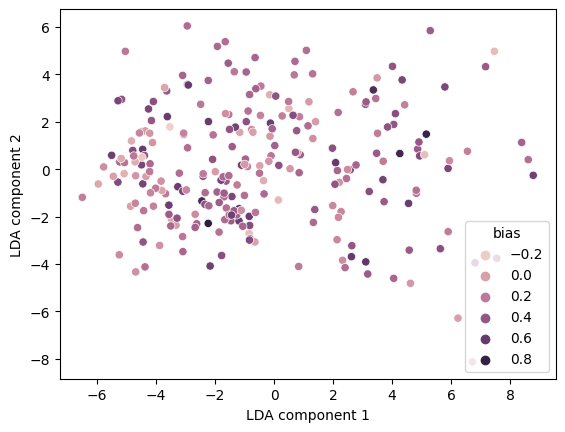

In [24]:
use_var = 'bias'
plot_data = df.groupby(['mouse_name', 'session'])[[0, 1, use_var]].mean().reset_index()

sns.scatterplot(x=0, y=1, hue=use_var, data=plot_data)
plt.xlabel('LDA component 1')
plt.ylabel('LDA component 2')

PearsonRResult(statistic=0.10683401266063244, pvalue=0.09254028982771105)


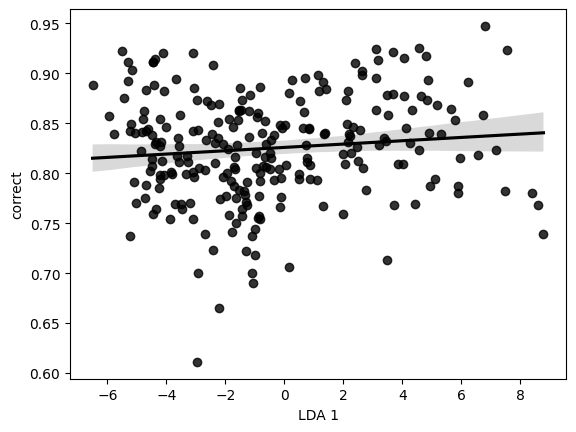

In [ ]:
component = 0
use_var = 'bias'
group_df = df.groupby(['mouse_name', use_var])[component].mean().reset_index()
# group_df = df.groupby(['mouse_name'])[[component, use_var]].mean().reset_index()

sns.regplot(x=np.array(group_df[component]).astype(float), y=(group_df[use_var]).astype(float),
            color='black', ci=95) 
plt.xlabel('LDA 1')
plt.ylabel(use_var)
res = stats.pearsonr(np.array(group_df[component]).astype(float), (group_df[use_var]).astype(float))
print(res)

# Previous code

In [106]:
data_path = prefix + 'representation_learning_variability/paper-individuality/1_segmentation/'
trials_file = pd.read_parquet(data_path+'all_trials_26-03-2026')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/1_segmentation/all_trials_26-03-2026'

In [21]:
trials_file.loc[trials_file['choice']=='left', 'choice'] = 0
trials_file.loc[trials_file['choice']=='right', 'choice'] = 1
# Compute block bias shift
# For zero contrast, difference in choice across blocks
block_df = trials_file.groupby(['session', 'block', 'contrast'])['choice'].mean().reset_index()
# block_df = states_file.groupby(['session', 'block'])['choice'].mean().reset_index()
bias_shift = block_df.loc[block_df['contrast']==0].pivot(index=['session'], columns=['block'], values=['choice'])
# bias_shift = block_df.pivot(index=['session'], columns=['block'], values=['choice'])
bias_shift['bias_shift'] = bias_shift[('choice', 0.8)] - bias_shift[('choice', 0.2)] 
bias_df = pd.DataFrame(np.array(bias_shift.reset_index()))
bias_df = bias_df.rename(columns={0:'session', 1:'0.2', 2:'0.5', 3:'0.8', 4:'bias'})
a = trials_file.groupby(['session', 'mouse_name'])[['reaction', 'elongation']].median().reset_index()
b = trials_file.groupby(['session', 'mouse_name'])[['correct', 'choice']].mean().reset_index()
merged = a.merge(b, on=['session', 'mouse_name'])
merged['log_reaction'] = np.log(merged['reaction'])
merged['log_elongation'] = np.log(merged['elongation'])
merged = merged.merge(bias_df[['session', 'bias']], on='session')

var = 'correct'
reduced_file = trials_file.groupby(['session', 'mouse_name'])[var].mean().reset_index()

merged_file = reduced_file.merge(clustered, on=['session', 'mouse_name'])

component = 0
sns.regplot(x=np.array(merged_file[component]).astype(float), y=(merged_file[var]).astype(float), ci=95) 
plt.xlabel('LDA 1')
plt.ylabel(var)

res = stats.pearsonr(np.array(merged_file[component]).astype(float), (merged_file[var]).astype(float))
print(res)

KeyError: "Columns not found: 'reaction', 'elongation'"

Correlation Results (Component × Variable):

Component 0:
  reaction    : r=-0.167, p=0.0084, p_corr=0.0506 
  bias        : r= 0.171, p=0.0067, p_corr=0.0402 ***
  correct     : r= 0.135, p=0.0334, p_corr=0.2001 

Component 1:
  reaction    : r= 0.186, p=0.0033, p_corr=0.0196 ***
  bias        : r= 0.031, p=0.6213, p_corr=1.0000 
  correct     : r= 0.024, p=0.7093, p_corr=1.0000 


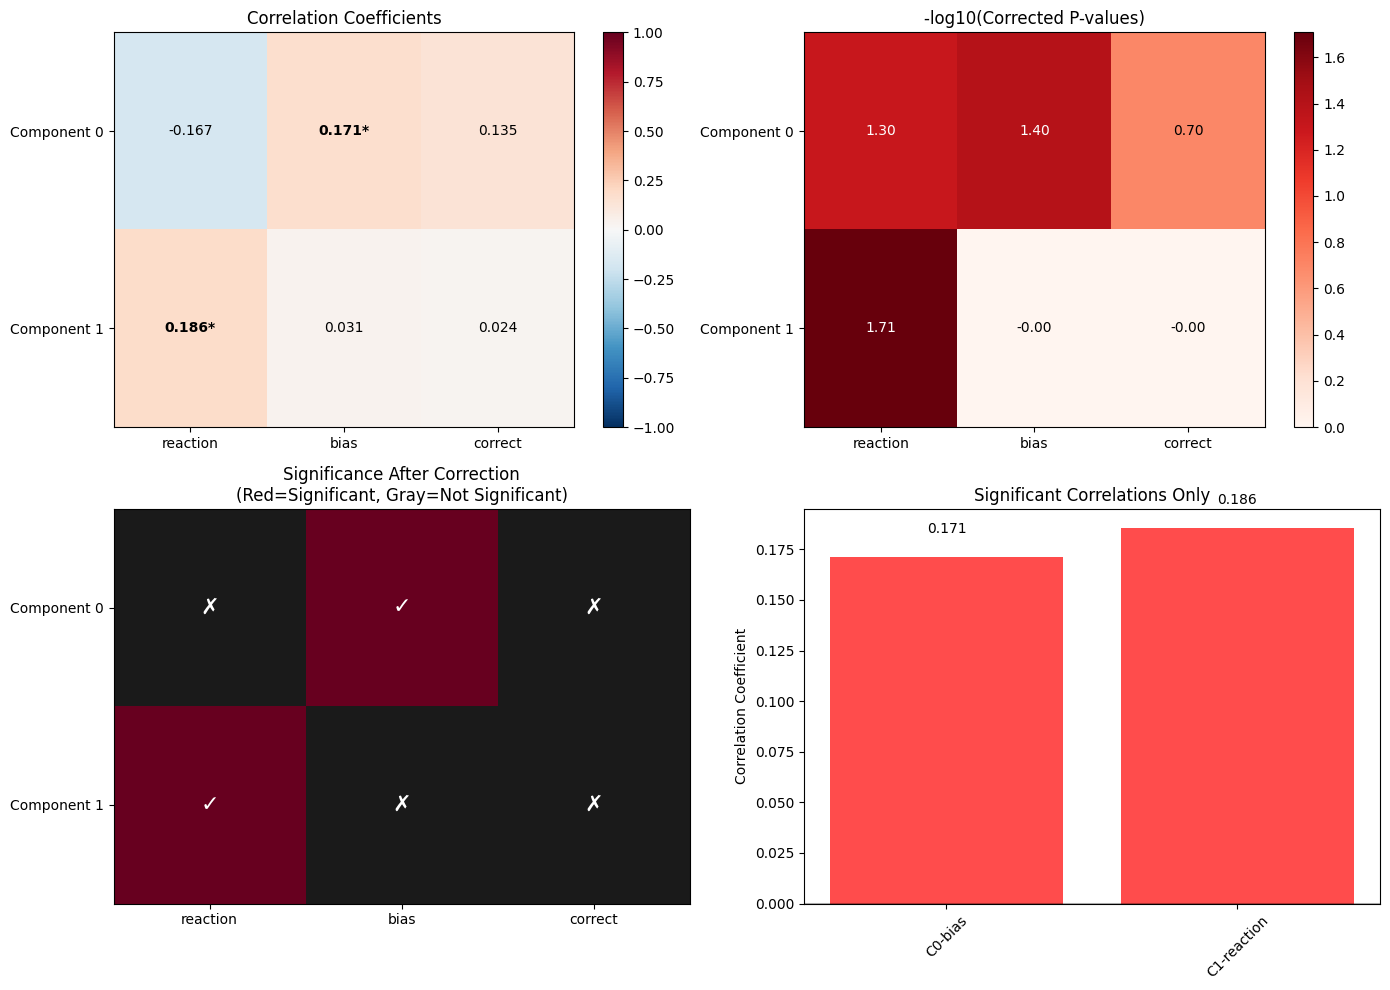


Total comparisons: 6
Significant correlations after Bonferroni correction: 2


In [371]:
# Define variables and components to analyze
variables = ['reaction', 'elongation', 'bias', 'correct']
variables = ['reaction', 'bias', 'correct']
components = [0, 1]

# Prepare the merged dataset with all variables
def prepare_variable_data(var):
    if var in ['reaction', 'elongation']:
        # Use median for reaction and elongation
        reduced_file = trials_file.groupby(['session', 'mouse_name'])[var].median().reset_index()
    elif var == 'bias':
        # Use the bias data we already computed
        reduced_file = bias_df[['session', 'bias']].rename(columns={'bias': var})
        # Add mouse_name by merging with a session-mouse mapping
        session_mouse = trials_file[['session', 'mouse_name']].drop_duplicates()
        reduced_file = reduced_file.merge(session_mouse, on='session')
    else:  # correct
        # Use mean for correct
        reduced_file = trials_file.groupby(['session', 'mouse_name'])[var].mean().reset_index()
    
    return reduced_file.merge(clustered, on=['session', 'mouse_name'])

# Compute all correlations and p-values
correlation_matrix = np.zeros((len(components), len(variables)))
pvalue_matrix = np.zeros((len(components), len(variables)))
all_pvalues = []  # For multiple comparison correction

for i, component in enumerate(components):
    for j, var in enumerate(variables):
        merged_var = prepare_variable_data(var)
        
        # Remove NaN values
        valid_mask = ~(pd.isna(merged_var[component]) | pd.isna(merged_var[var]))
        
        if valid_mask.sum() > 0:
            corr, p_val = stats.pearsonr(
                np.array(merged_var.loc[valid_mask, component]).astype(float),
                np.array(merged_var.loc[valid_mask, var]).astype(float)
            )
            correlation_matrix[i, j] = corr
            pvalue_matrix[i, j] = p_val
            all_pvalues.append(p_val)
        else:
            correlation_matrix[i, j] = np.nan
            pvalue_matrix[i, j] = np.nan
            all_pvalues.append(np.nan)

# Apply Bonferroni correction for multiple comparisons (12 total comparisons)
from statsmodels.stats.multitest import multipletests
corrected_pvalues = multipletests(all_pvalues, method='bonferroni')[1]

# Reshape corrected p-values back to matrix form
corrected_pvalue_matrix = np.array(corrected_pvalues).reshape(len(components), len(variables))

# Create significance matrix
significance_matrix = corrected_pvalue_matrix < 0.05

# Print results table
print("Correlation Results (Component × Variable):")
print("=" * 60)
for i, component in enumerate(components):
    print(f"\nComponent {component}:")
    for j, var in enumerate(variables):
        corr = correlation_matrix[i, j]
        p_orig = pvalue_matrix[i, j]
        p_corr = corrected_pvalue_matrix[i, j]
        sig = "***" if significance_matrix[i, j] else ""
        print(f"  {var:12s}: r={corr:6.3f}, p={p_orig:.4f}, p_corr={p_corr:.4f} {sig}")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Correlation heatmap
im1 = axes[0, 0].imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0, 0].set_xticks(range(len(variables)))
axes[0, 0].set_yticks(range(len(components)))
axes[0, 0].set_xticklabels(variables)
axes[0, 0].set_yticklabels([f'Component {i}' for i in components])
axes[0, 0].set_title('Correlation Coefficients')
plt.colorbar(im1, ax=axes[0, 0])

# Add correlation values and significance markers
for i in range(len(components)):
    for j in range(len(variables)):
        text = f'{correlation_matrix[i, j]:.3f}'
        if significance_matrix[i, j]:
            text = f'{text}*'
        axes[0, 0].text(j, i, text, ha='center', va='center',
                       color='white' if abs(correlation_matrix[i, j]) > 0.5 else 'black',
                       fontweight='bold' if significance_matrix[i, j] else 'normal')

# 2. P-value heatmap (log scale)
log_pvalues = -np.log10(corrected_pvalue_matrix)
im2 = axes[0, 1].imshow(log_pvalues, cmap='Reds', aspect='auto')
axes[0, 1].set_xticks(range(len(variables)))
axes[0, 1].set_yticks(range(len(components)))
axes[0, 1].set_xticklabels(variables)
axes[0, 1].set_yticklabels([f'Component {i}' for i in components])
axes[0, 1].set_title('-log10(Corrected P-values)')
plt.colorbar(im2, ax=axes[0, 1])

# Add significance threshold line and values
for i in range(len(components)):
    for j in range(len(variables)):
        text = f'{log_pvalues[i, j]:.2f}'
        axes[0, 1].text(j, i, text, ha='center', va='center',
                       color='white' if log_pvalues[i, j] > 1 else 'black')

# 3. Significance matrix
im3 = axes[1, 0].imshow(significance_matrix.astype(int), cmap='RdGy_r', aspect='auto', vmin=0, vmax=1)
axes[1, 0].set_xticks(range(len(variables)))
axes[1, 0].set_yticks(range(len(components)))
axes[1, 0].set_xticklabels(variables)
axes[1, 0].set_yticklabels([f'Component {i}' for i in components])
axes[1, 0].set_title('Significance After Correction\n(Red=Significant, Gray=Not Significant)')

# Add significance markers
for i in range(len(components)):
    for j in range(len(variables)):
        text = '✓' if significance_matrix[i, j] else '✗'
        axes[1, 0].text(j, i, text, ha='center', va='center',
                       color='white', fontsize=16, fontweight='bold')

# 4. Bar plot summary of significant correlations
significant_corrs = correlation_matrix[significance_matrix]
significant_labels = []
for i in range(len(components)):
    for j in range(len(variables)):
        if significance_matrix[i, j]:
            significant_labels.append(f'C{i}-{variables[j]}')

if len(significant_corrs) > 0:
    colors = ['red' if corr > 0 else 'blue' for corr in significant_corrs]
    bars = axes[1, 1].bar(range(len(significant_corrs)), significant_corrs, color=colors, alpha=0.7)
    axes[1, 1].set_xticks(range(len(significant_corrs)))
    axes[1, 1].set_xticklabels(significant_labels, rotation=45)
    axes[1, 1].set_ylabel('Correlation Coefficient')
    axes[1, 1].set_title('Significant Correlations Only')
    axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add values on bars
    for bar, corr in zip(bars, significant_corrs):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + (0.01 if height >= 0 else -0.03),
                       f'{corr:.3f}', ha='center', va='bottom' if height >= 0 else 'top')
else:
    axes[1, 1].text(0.5, 0.5, 'No Significant\nCorrelations', ha='center', va='center',
                   transform=axes[1, 1].transAxes, fontsize=14)
    axes[1, 1].set_title('Significant Correlations Only')

plt.tight_layout()
plt.show()

print(f"\nTotal comparisons: {len(components) * len(variables)}")
print(f"Significant correlations after Bonferroni correction: {np.sum(significance_matrix)}")

PearsonRResult(statistic=np.float64(0.13490499512047233), pvalue=np.float64(0.033354511237247))


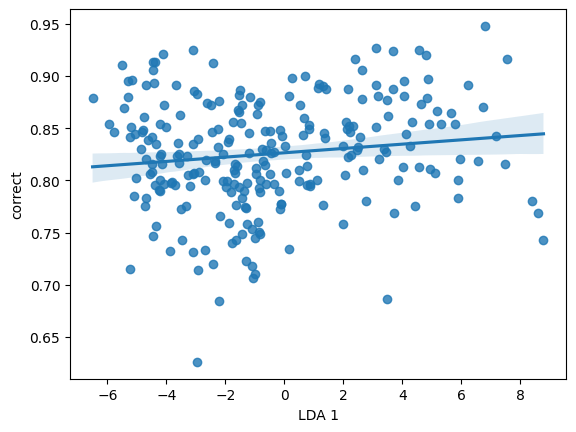

In [ ]:
var = 'correct'
reduced_file = trials_file.groupby(['session', 'mouse_name'])[var].mean().reset_index()

merged_file = reduced_file.merge(clustered, on=['session', 'mouse_name'])

component = 0
sns.regplot(x=np.array(merged_file[component]).astype(float), y=(merged_file[var]).astype(float), ci=95) 
plt.xlabel('LDA 1')
plt.ylabel(var)

res = stats.pearsonr(np.array(merged_file[component]).astype(float), (merged_file[var]).astype(float))
print(res)

In [ ]:
test_df = clustered.merge(states_file, on='mouse_name')
learning_df['log_training'] = np.log(learning_df['training_time'])

# Trial modes

In [141]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
trial_clusters = pd.read_parquet(data_path+'17_trial_waterclust')

In [142]:
group_cols = ['mouse_name', 'session']

# Count syllables per group
data = (
    trial_clusters
    .groupby(group_cols + ['trial_cluster'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))
new_clustered = clustered.copy()
new_clustered['session'] = np.array(session_syllables.reset_index()['session'])

joint = data.merge(new_clustered, on=['mouse_name', 'session'])

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_23830/1091089324.py:5: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



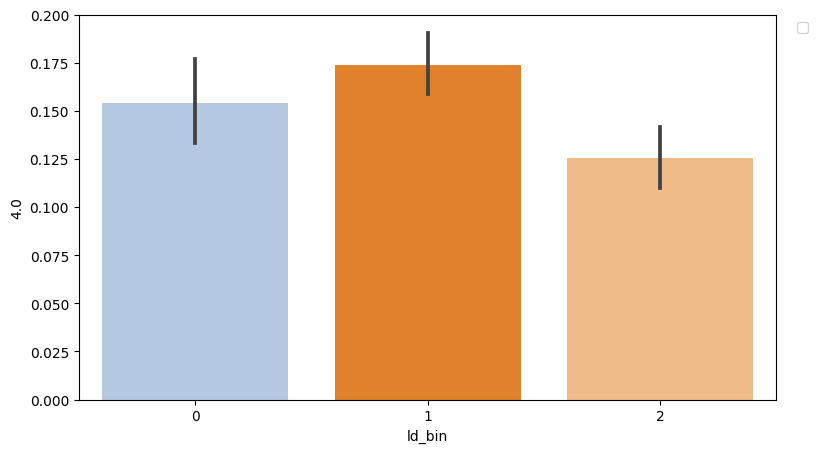

In [308]:
n_bins = 3
joint['ld_bin'] = pd.qcut(joint['LD1'], n_bins, labels=False)
plt.figure(figsize=(9,5))
sns.barplot(y=4, x='ld_bin', data=joint, palette=scatter_colors)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')


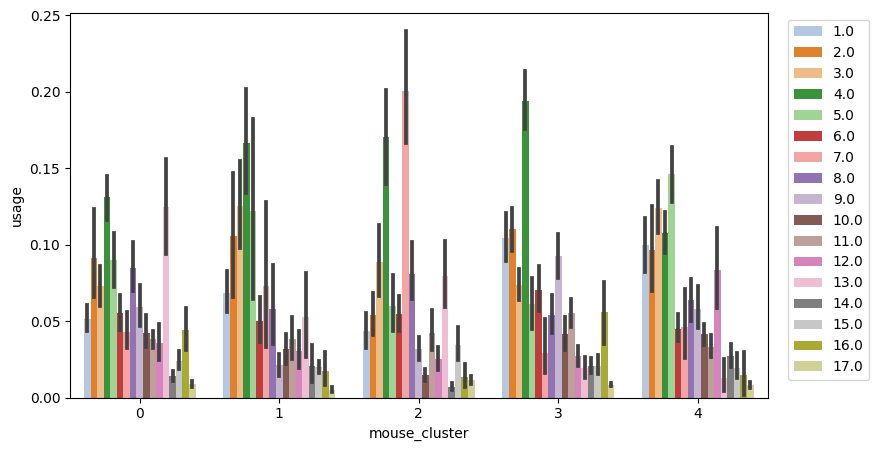

In [296]:
plt.figure(figsize=(9,5))
sns.barplot(hue='trial_cluster', y='usage', x='mouse_cluster', data=joint, palette=scatter_colors)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')


In [143]:
group_cols = ['mouse_name', 'session']

# Count syllables per group
data = (
    trial_clusters
    .groupby(group_cols + ['trial_cluster'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

group_cols = ['mouse_name', 'session']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['trial_cluster']).reset_index().fillna(0)

lda_df = clustered.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
lda_df = lda_df[['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'mouse_name', 'lab',
          'lab_number', 'litter_id', 'litter_number', 'mouse_cluster']]
lda_df['session'] = np.array(session_syllables.reset_index()['session'])

joint = data.merge(lda_df, on=['session', 'mouse_name'])

In [144]:
ld = 'LD1'
trial_modes = np.arange(1, 18, 1)
# sort by LDA
df_sorted = joint.sort_values(ld)

# bin along LD axis
n_bins = 5
df_sorted['ld_bin'] = pd.qcut(df_sorted[ld], n_bins, labels=False)

# average composition per bin
bin_means = df_sorted.groupby('ld_bin')[trial_modes].mean()


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarn

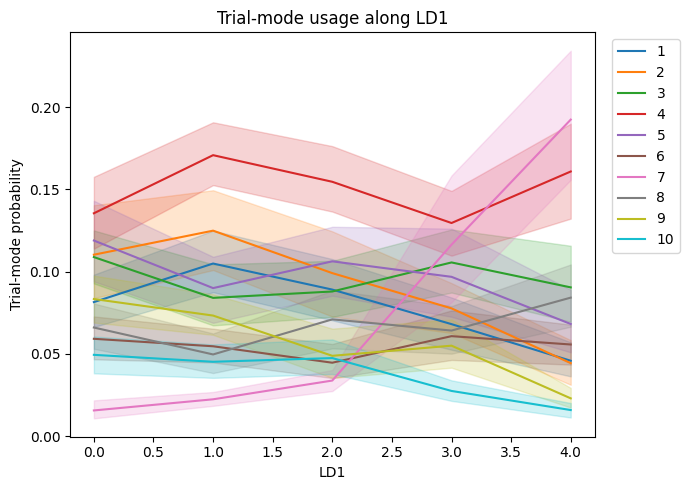

In [145]:
plt.figure(figsize=(7,5))

for col in trial_modes[:10]:
    sns.lineplot(x='ld_bin', y=col, data=df_sorted, label=col)

plt.xlabel('LD1')
plt.ylabel('Trial-mode probability')
plt.title('Trial-mode usage along LD1')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()
# sns.lineplot(x='ld_bin', y=1, data=df_sorted)

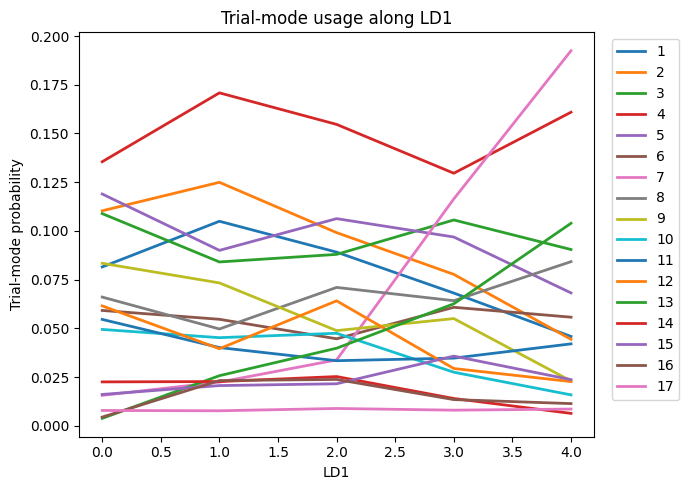

In [146]:
plt.figure(figsize=(7,5))

for col in trial_modes:
    plt.plot(
        np.arange(0, n_bins, 1),
        bin_means[col],
        label=col,
        linewidth=2
    )

plt.xlabel('LD1')
plt.ylabel('Trial-mode probability')
plt.title('Trial-mode usage along LD1')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()



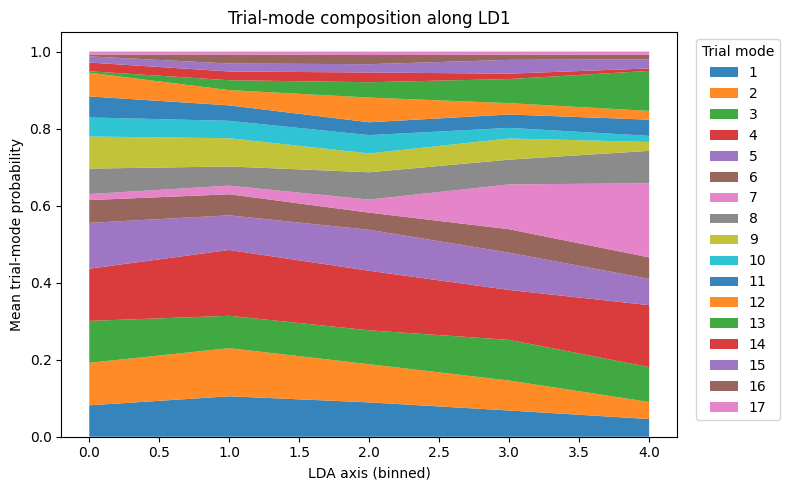

In [147]:
plt.figure(figsize=(8,5))

x = np.arange(len(bin_means))
y = bin_means.T.values  # shape: (n_trials, n_bins)

plt.stackplot(x, y, labels=trial_modes, alpha=0.9)

plt.xlabel('LDA axis (binned)')
plt.ylabel('Mean trial-mode probability')
plt.title('Trial-mode composition along LD1')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
    title='Trial mode')

plt.tight_layout()
plt.show()


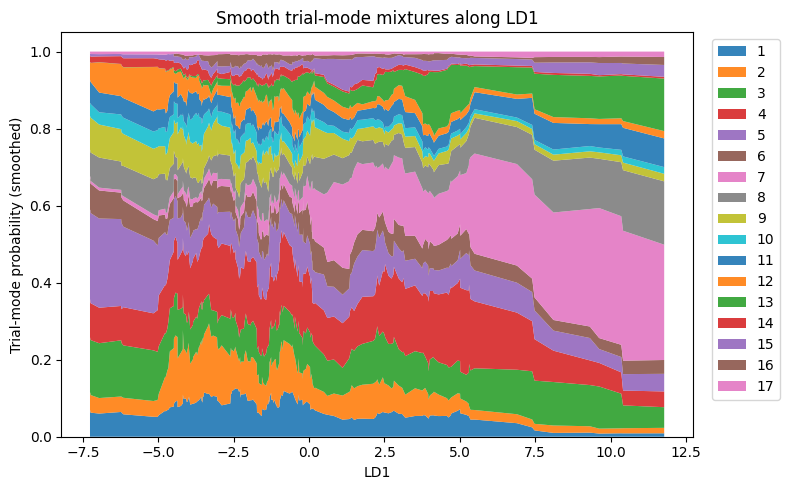

In [148]:
window = 10  # controls smoothness
df_smooth = df_sorted.copy()
for col in trial_modes:
    df_smooth[col] = df_smooth[col].rolling(
        window, center=True, min_periods=1).mean()
plt.figure(figsize=(8,5))

x = df_smooth[ld].values
y = df_smooth[trial_modes].values.T

plt.stackplot(
    x,
    y,
    labels=trial_modes,
    alpha=0.9)

plt.xlabel('LD1')
plt.ylabel('Trial-mode probability (smoothed)')
plt.title('Smooth trial-mode mixtures along LD1')

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left')

plt.tight_layout()
plt.show()



/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_26339/660693113.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_26339/660693113.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_26339/660693113.py:30: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_26339/660693113.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called wit

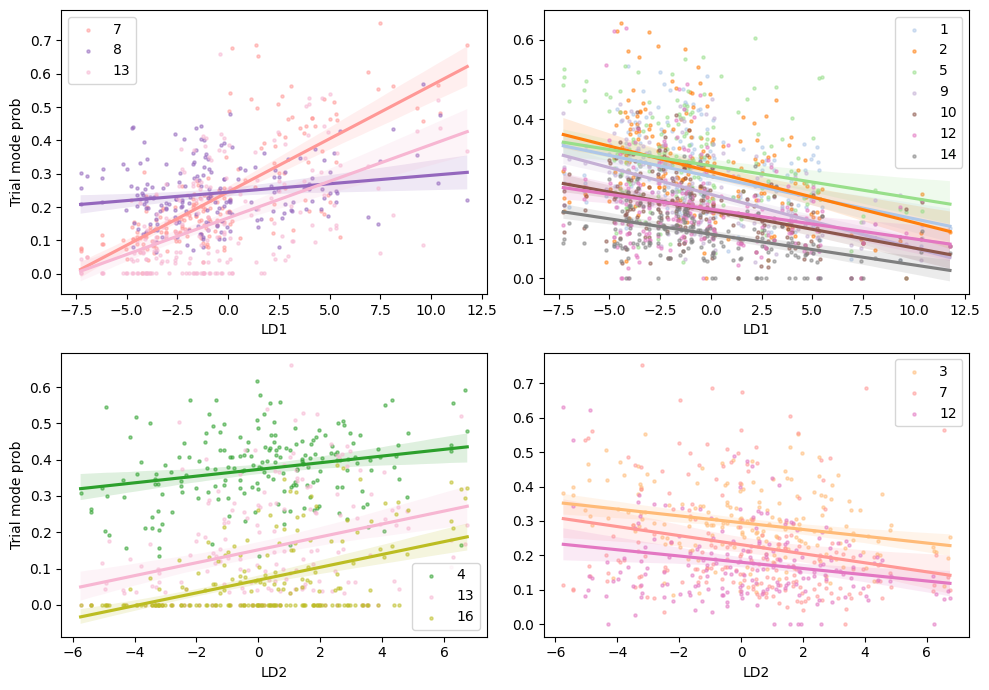

In [151]:
trial_modes = np.arange(1, 18, 1)
cmap = plt.get_cmap("tab20")
clusters = np.unique(trial_modes)
color_dict = {
    k: cmap(k % cmap.N)   # exact tab20 color
    for k in clusters}
scatter_colors = np.array([color_dict[k] for k in trial_modes])

fig, axs = plt.subplots(2, 2, sharex=False, sharey=False, figsize=(10, 7))

for t, trial in enumerate(trial_modes):
    palette = sns.color_palette('Set2', 8)
    for l, ld in enumerate(['LD1', 'LD2']):

            ld_data = joint[ld]
            trial_data = np.sqrt(joint[trial]+.000001)
            res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(trial_data.astype(float)))
            if res[0]>0 and res[1] < 0.01:
                sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(trial_data.astype(float)), 
                            ax=axs[l, 0], ci=95, color=color_dict[trial], label=str(trial), 
                            scatter_kws=dict(alpha=0.5, s=5, color=color_dict[trial])) # label=str(np.round(res[1], 3))
            elif res[0]<0 and res[1] < 0.01:
                sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(trial_data.astype(float)), 
                            ax=axs[l, 1], ci=95, color=color_dict[trial], label=str(trial), 
                            scatter_kws=dict(alpha=0.5, s=5, color=color_dict[trial]))
            axs[l, 0].set_xlabel(ld)
            axs[l, 1].set_xlabel(ld)
            axs[l, 0].set_ylabel('Trial mode prob')
            axs[l, 0].legend()
            axs[l, 1].legend()
            # axs[1, l].set_title(ld)

    plt.tight_layout()

## Paw states

In [280]:
identifiable_mapping = {'000': 0.0,
        '100': 1.0,
        '200': 2.0,
        '300': 3.0,
        '400': 4.0,
        '500': 5.0,
        '600': 6.0,
        '700': 7.0,
        
        '010': 8.0,
        '110': 9.0,
        '210': 10.0,
        '310': 11.0,
        '410': 12.0,
        '510': 13.0,
        '610': 14.0,
        '710': 15.0,

        '001': 16.0,
        '101': 17.0,
        '201': 18.0,
        '301': 19.0, 
        '401': 20.0, 
        '501': 21.0, 
        '601': 22.0, 
        '701': 23.0, 

        '011': 24.0,
        '111': 25.0,
        '211': 26.0,
        '311': 27.0,
        '411': 28.0,
        '511': 29.0,
        '611': 30.0,
        '711': 31.0,
        'nan': np.nan
        }

inverted_mapping = {v: k for k, v in identifiable_mapping.items()}
inverted_func = np.vectorize(inverted_mapping.get)
order = ['000', '010', '001', '011', '100', '110', '101', '111', '200', '210', '201', '211',
         '300', '310', '301', '311', '400', '410',  '401', '411',
         '500', '510', '501', '511', '600', '610', '601', '611',
         '700', '710', '701', '711']
labels = ['0', '0', '0', '0', 
          '1', '1', '1', '1',
          '2', '2', '2', '2',
          '3', '3', '3', '3',
          '4', '4', '4', '4',
          '5', '5', '5', '5',
          '6', '6', '6', '6',
          '7', '7', '7', '7']

rename_labels = dict(zip(np.array(order), np.array(labels)))
rename_func = np.vectorize(rename_labels.get)

In [281]:
states_file['paw_states'] = rename_func(inverted_func(states_file['most_likely_states']))

In [282]:
group_cols = ['mouse_name', 'session', 'broader_label']
# group_cols = ['mouse_name', 'session']
# group_cols = ['mouse_name', 'broader_label']

# Count syllables per group
data = (
    states_file
    .groupby(group_cols + ['paw_states'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

group_cols = ['mouse_name', 'session', 'broader_label']
# group_cols = ['mouse_name']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['paw_states']).reset_index().fillna(0)

lda_df = clustered.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
lda_df = lda_df[['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'mouse_name', 'lab',
          'lab_number', 'litter_id', 'litter_number', 'mouse_cluster']]
lda_df['session'] = np.array(session_syllables.reset_index()['session'])

# lda_df = lda_df.loc[lda_df['LD1']>-15]

joint = data.merge(lda_df, on=['session', 'mouse_name'])

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7985/73674196.py:18: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7985/73674196.py:18: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7985/73674196.py:18: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7985/73674196.py:18: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no arg

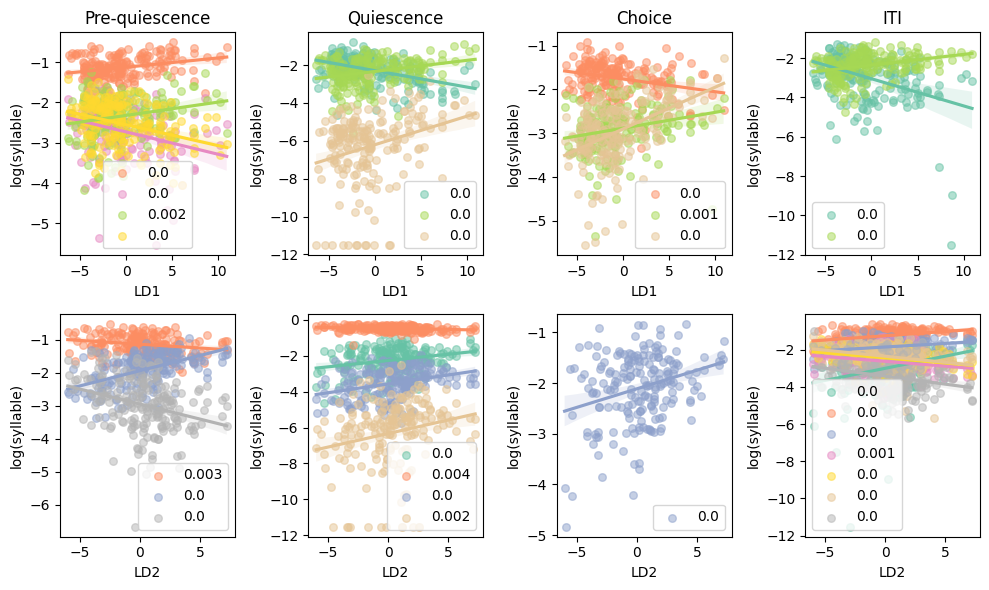

In [283]:
fig, axs = plt.subplots(2, 4, sharex=False, sharey=False, figsize=(10, 6))
palette = sns.color_palette('Set2', 8)
# for l, ld in enumerate(['LD1', 'LD2', 'LD3', 'LD4', 'LD5']):
for l, ld in enumerate(['LD1', 'LD2']):
    for e, epoch in enumerate(['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']):
        epoch_data = joint.loc[joint['broader_label']==epoch].dropna()
        for p, paw in enumerate(['0', '1', '2', '3', '4', '5', '6', '7']):
            paw_data = np.log(epoch_data[paw]+0.00001)
            # paw_data = np.sqrt(epoch_data[paw])
            ld_data = epoch_data[ld]
            res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(paw_data.astype(float)))
            if res[1] < 0.01:
                sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(paw_data.astype(float)), 
                            ax=axs[l, e], ci=95, color=palette[p], label=str(np.round(res[1], 3)), 
                            scatter_kws=dict(alpha=0.5, s=30, color=palette[p]))
            axs[l, e].set_xlabel(ld)
            axs[l, e].set_ylabel('log(syllable)')
            axs[l, e].legend()
        axs[0, e].set_title(epoch)

plt.tight_layout()

In [100]:
group_cols = ['mouse_name', 'session']
# Count syllables per group
data = (
    states_file
    .groupby(group_cols + ['paw_states'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

group_cols = ['mouse_name', 'session']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['paw_states']).reset_index().fillna(0)

lda_df = clustered.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
lda_df = lda_df[['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'mouse_name', 'lab',
          'lab_number', 'litter_id', 'litter_number', 'mouse_cluster']]
lda_df['session'] = np.array(session_syllables.reset_index()['session'])

lda_df = lda_df.loc[lda_df['LD1']>-15]

joint = data.merge(lda_df, on=['session', 'mouse_name'])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


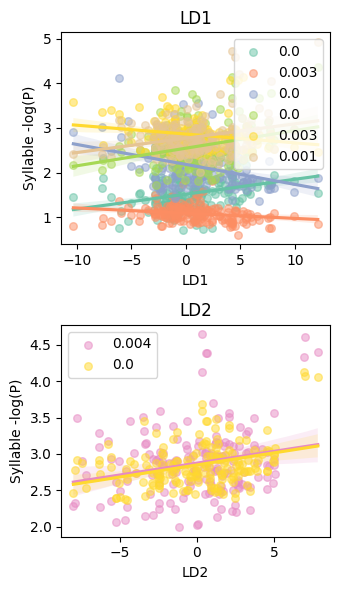

In [105]:
fig, axs = plt.subplots(2, sharex=False, sharey=False, figsize=(3.5, 6))
palette = sns.color_palette('Set2', 8)
# for l, ld in enumerate(['LD1', 'LD2', 'LD3', 'LD4', 'LD5']):
for l, ld in enumerate(['LD1', 'LD2']):
    for p, paw in enumerate(['0', '1', '2', '3', '4', '5', '6', '7']):
        paw_data = -np.log(joint[paw])
        # paw_data = np.sqrt(epoch_data[paw])
        ld_data = joint[ld]
        res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(paw_data.astype(float)))
        if res[1] < 0.01:
            sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(paw_data.astype(float)), 
                        ax=axs[l], ci=95, color=palette[p], label=str(np.round(res[1], 3)), 
                        scatter_kws=dict(alpha=0.5, s=30, color=palette[p]))
        axs[l].set_xlabel(ld)
        axs[l].set_ylabel('Syllable -log(P)')
        axs[l].legend()
        axs[l].set_title(ld)

plt.tight_layout()

## Lick/whisk states

In [192]:
order = ['000', '010', '001', '011', '100', '110', '101', '111', '200', '210', '201', '211',
         '300', '310', '301', '311', '400', '410',  '401', '411',
         '500', '510', '501', '511', '600', '610', '601', '611',
         '700', '710', '701', '711']
labels = ['No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick', 
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick']

rename_labels = dict(zip(np.array(order), np.array(labels)))
rename_func = np.vectorize(rename_labels.get)


In [193]:
states_file['whisk_lick'] = rename_func(inverted_func(states_file['most_likely_states']))

In [194]:
group_cols = ['mouse_name', 'session', 'broader_label']
# group_cols = ['mouse_name', 'broader_label']

# Count syllables per group
data = (
    states_file
    .groupby(group_cols + ['whisk_lick'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

group_cols = ['mouse_name', 'session', 'broader_label']
# group_cols = ['mouse_name']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['whisk_lick']).reset_index().fillna(0)

lda_df = clustered.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
lda_df = lda_df[['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'mouse_name', 'lab',
          'lab_number', 'litter_id', 'litter_number', 'mouse_cluster']]
lda_df['session'] = np.array(session_syllables.reset_index()['session'])

lda_df = lda_df.loc[lda_df['LD1']>-15]

joint = data.merge(lda_df, on=['session', 'mouse_name'])

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/691725429.py:21: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/691725429.py:21: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/691725429.py:21: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/691725429.py:21: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called wit

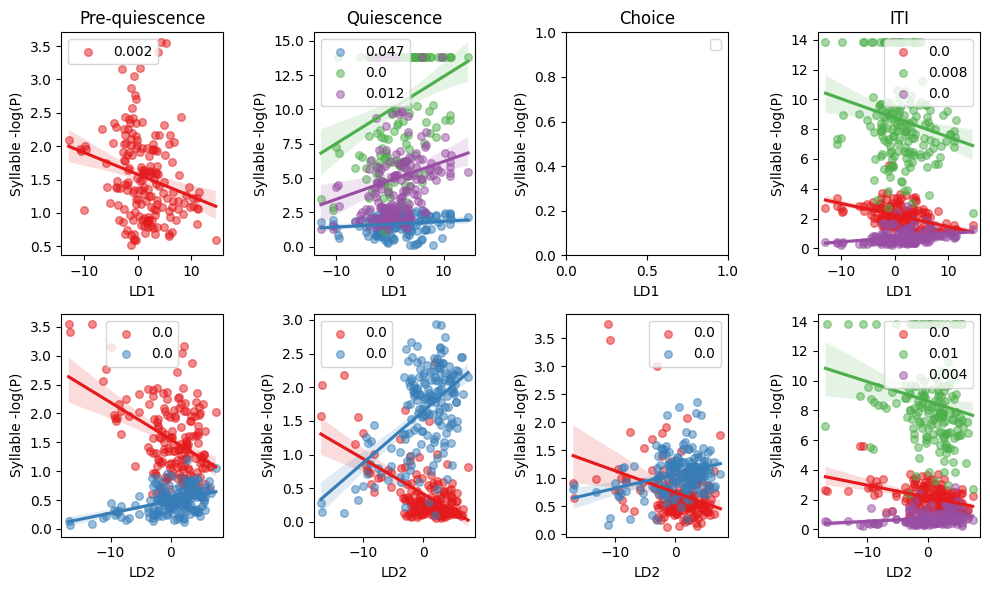

In [196]:
fig, axs = plt.subplots(2, 4, sharex=False, sharey=False, figsize=(10, 6))
palette = sns.color_palette('Set1', 4)
for l, ld in enumerate(['LD1', 'LD2']):
    for e, epoch in enumerate(['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']):
        epoch_data = joint.loc[joint['broader_label']==epoch].dropna()
        for p, paw in enumerate(['No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick']):
            paw_data = -np.log(epoch_data[paw]+0.000001)
            # paw_data = np.sqrt(epoch_data[paw])
            ld_data = epoch_data[ld]
            res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(paw_data.astype(float)))
            if res[1] < 0.05:
                sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(paw_data.astype(float)), 
                            ax=axs[l, e], ci=95, color=palette[p], label=str(np.round(res[1], 3)), 
                            scatter_kws=dict(alpha=0.5, s=30, color=palette[p]))
            # if l== 1:
            #     sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(paw_data.astype(float)), 
            #                 ax=axs[l, e], ci=95, color=palette[p], label=paw, 
            #                 scatter_kws=dict(alpha=0.5, s=30, color=palette[p]))
            axs[l, e].set_xlabel(ld)
            axs[l, e].set_ylabel('Syllable -log(P)')
            axs[l, e].legend()

        axs[0, e].set_title(epoch)

plt.tight_layout()

In [197]:
group_cols = ['mouse_name', 'session']
# Count syllables per group
data = (
    states_file
    .groupby(group_cols + ['whisk'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

group_cols = ['mouse_name', 'session']
# group_cols = ['mouse_name']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['whisk']).reset_index().fillna(0)

lda_df = clustered.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
lda_df = lda_df[['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'mouse_name', 'lab',
          'lab_number', 'litter_id', 'litter_number', 'mouse_cluster']]
lda_df['session'] = np.array(session_syllables.reset_index()['session'])
lda_df = lda_df.loc[lda_df['LD1']>-15]
joint = data.merge(lda_df, on=['session', 'mouse_name'])

KeyError: 'whisk'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


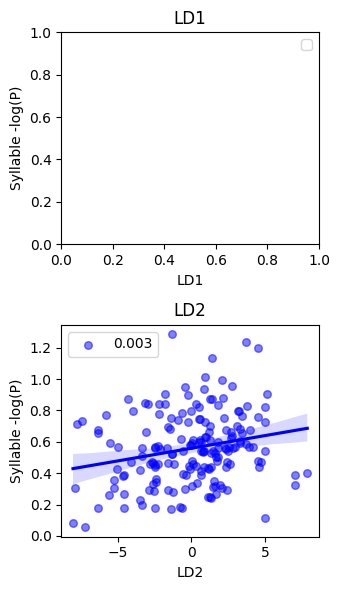

In [ ]:
fig, axs = plt.subplots(2, sharex=False, sharey=False, figsize=(3.5, 6))
palette = sns.color_palette('Set2', 8)
for l, ld in enumerate(['LD1', 'LD2']):
    for p, paw in enumerate(['Whisk']):
        paw_data = -np.log(joint[paw]+0.000001)
        # paw_data = np.sqrt(epoch_data[paw])
        ld_data = joint[ld]
        res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(paw_data.astype(float)))
        if res[1] < 0.01:
            sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(paw_data.astype(float)), 
                        ax=axs[l], ci=95, color='blue', label=str(np.round(res[1], 3)), 
                        scatter_kws=dict(alpha=0.5, s=30, color='blue'))
        axs[l].set_xlabel(ld)
        axs[l].set_ylabel('Syllable -log(P)')
        axs[l].legend()
        axs[l].set_title(ld)

group_cols = ['mouse_name', 'session']
# Count syllables per group
data = (
    states_file
    .groupby(group_cols + ['lick'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

group_cols = ['mouse_name', 'session']
# group_cols = ['mouse_name']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['lick']).reset_index().fillna(0)

lda_df = clustered.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
lda_df = lda_df[['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'mouse_name', 'lab',
          'lab_number', 'litter_id', 'litter_number', 'mouse_cluster']]
lda_df['session'] = np.array(session_syllables.reset_index()['session'])
lda_df = lda_df.loc[lda_df['LD1']>-15]
joint = data.merge(lda_df, on=['session', 'mouse_name'])

for l, ld in enumerate(['LD1', 'LD2']):
    for p, paw in enumerate(['Lick']):
        paw_data = -np.log(joint[paw]+0.000001)
        # paw_data = np.sqrt(epoch_data[paw])
        ld_data = joint[ld]
        res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(paw_data.astype(float)))
        if res[1] < 0.01:
            sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(paw_data.astype(float)), 
                        ax=axs[l], ci=95, color='red', label=str(np.round(res[1], 3)), 
                        scatter_kws=dict(alpha=0.5, s=30, color='red'))
        axs[l].set_xlabel(ld)
        axs[l].set_ylabel('Syllable -log(P)')
        axs[l].legend()
        axs[l].set_title(ld)

plt.tight_layout()

## Lick whisk states

In [284]:
order = ['000', '010', '001', '011', '100', '110', '101', '111', '200', '210', '201', '211',
         '300', '310', '301', '311', '400', '410',  '401', '411',
         '500', '510', '501', '511', '600', '610', '601', '611',
         '700', '710', '701', '711']
labels = ['No whisk', 'Whisk', 'No whisk', 'Whisk',  
          'No whisk', 'Whisk', 'No whisk', 'Whisk',  
          'No whisk', 'Whisk', 'No whisk', 'Whisk',    
          'No whisk', 'Whisk', 'No whisk', 'Whisk',    
          'No whisk', 'Whisk', 'No whisk', 'Whisk',   
          'No whisk', 'Whisk', 'No whisk', 'Whisk',    
          'No whisk', 'Whisk', 'No whisk', 'Whisk',  
          'No whisk', 'Whisk', 'No whisk', 'Whisk',  ]

rename_labels = dict(zip(np.array(order), np.array(labels)))
rename_func = np.vectorize(rename_labels.get)


In [285]:
states_file['whisk'] = rename_func(inverted_func(states_file['most_likely_states']))

In [286]:
order = ['000', '010', '001', '011', '100', '110', '101', '111', '200', '210', '201', '211',
         '300', '310', '301', '311', '400', '410',  '401', '411',
         '500', '510', '501', '511', '600', '610', '601', '611',
         '700', '710', '701', '711']
labels = ['No lick', 'No lick', 'Lick', 'Lick',
          'No lick', 'No lick', 'Lick', 'Lick',
          'No lick', 'No lick', 'Lick', 'Lick',   
          'No lick', 'No lick', 'Lick', 'Lick',   
          'No lick', 'No lick', 'Lick', 'Lick',  
          'No lick', 'No lick', 'Lick', 'Lick',    
          'No lick', 'No lick', 'Lick', 'Lick',  
          'No lick', 'No lick', 'Lick', 'Lick',]

rename_labels = dict(zip(np.array(order), np.array(labels)))
rename_lick = np.vectorize(rename_labels.get)
states_file['lick'] = rename_lick(inverted_func(states_file['most_likely_states']))

In [287]:
group_cols = ['mouse_name', 'session', 'broader_label']
# group_cols = ['mouse_name', 'broader_label']

# Count syllables per group
data = (
    states_file
    .groupby(group_cols + ['whisk'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

group_cols = ['mouse_name', 'session', 'broader_label']
# group_cols = ['mouse_name']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['whisk']).reset_index().fillna(0)

In [288]:
lda_df = clustered.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
lda_df = lda_df[['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'mouse_name', 'lab',
          'lab_number', 'litter_id', 'litter_number', 'mouse_cluster']]
lda_df['session'] = np.array(session_syllables.reset_index()['session'])

lda_df = lda_df.loc[lda_df['LD1']>-15]

joint = data.merge(lda_df, on=['session', 'mouse_name'])

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7985/1223993205.py:17: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7985/1223993205.py:17: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7985/1223993205.py:17: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_7985/1223993205.py:17: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called wit

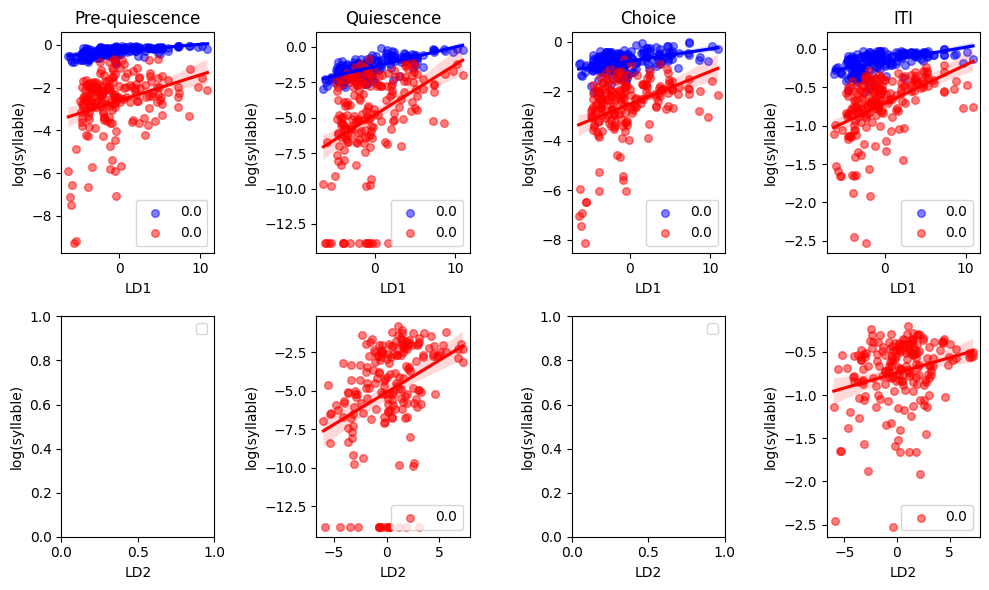

In [289]:
fig, axs = plt.subplots(2, 4, sharex=False, sharey=False, figsize=(10, 6))
palette = sns.color_palette('Set1', 4)
for l, ld in enumerate(['LD1', 'LD2']):
    for e, epoch in enumerate(['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']):
        epoch_data = joint.loc[joint['broader_label']==epoch].dropna()
        for p, paw in enumerate(['Whisk']):
            paw_data = np.log(epoch_data[paw]+0.000001)
            # paw_data = np.sqrt(epoch_data[paw])
            ld_data = epoch_data[ld]
            res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(paw_data.astype(float)))
            if res[1] < 0.05:
                sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(paw_data.astype(float)), 
                            ax=axs[l, e], ci=95, color='blue', label=str(np.round(res[1], 3)), 
                            scatter_kws=dict(alpha=0.5, s=30, color='blue'))
            axs[l, e].set_xlabel(ld)
            axs[l, e].set_ylabel('log(syllable)')
            axs[l, e].legend()

        axs[0, e].set_title(epoch)


group_cols = ['mouse_name', 'session', 'broader_label']
# group_cols = ['mouse_name', 'broader_label']
# Count syllables per group
data = (
    states_file
    .groupby(group_cols + ['lick'])
    .size()
    .reset_index(name='count'))
# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))
group_cols = ['mouse_name', 'session', 'broader_label']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['lick']).reset_index().fillna(0)
lda_df = clustered.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
lda_df = lda_df[['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'mouse_name', 'lab',
          'lab_number', 'litter_id', 'litter_number', 'mouse_cluster']]
lda_df['session'] = np.array(session_syllables.reset_index()['session'])
lda_df = lda_df.loc[lda_df['LD1']>-15]
joint = data.merge(lda_df, on=['session', 'mouse_name'])

for l, ld in enumerate(['LD1', 'LD2']):
    for e, epoch in enumerate(['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']):
        epoch_data = joint.loc[joint['broader_label']==epoch].dropna()
        for p, paw in enumerate(['Lick']):
            paw_data = np.log(epoch_data[paw]+0.000001)
            # paw_data = np.sqrt(epoch_data[paw])
            ld_data = epoch_data[ld]
            res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(paw_data.astype(float)))
            if res[1] < 0.05:
                sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(paw_data.astype(float)), 
                            ax=axs[l, e], ci=95, color='red', label=str(np.round(res[1], 3)), 
                            scatter_kws=dict(alpha=0.5, s=30, color='red'))
            axs[l, e].set_xlabel(ld)
            axs[l, e].set_ylabel('log(syllable)')
            axs[l, e].legend()

        axs[0, e].set_title(epoch)
plt.tight_layout()

# Trial-level descriptors

In [226]:
lda_df = clustered.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
lda_df = lda_df[['LD1', 'LD2', 'LD3', 'LD4', 'LD5', 'LD6', 'mouse_name', 'lab',
          'lab_number', 'litter_id', 'litter_number', 'mouse_cluster']]
lda_df['session'] = np.array(session_syllables.reset_index()['session'])


lda_df = lda_df.loc[lda_df['LD1']>-15]


joint = data.merge(lda_df, on=['session', 'mouse_name'])

In [227]:
states_file['binary_choice'] = states_file['choice']
states_file.loc[states_file['choice']=='left', 'binary_choice'] = 0.0
states_file.loc[states_file['choice']=='right', 'binary_choice'] = 1.0

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/76687812.py:23: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/76687812.py:23: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/76687812.py:23: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/76687812.py:23: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no

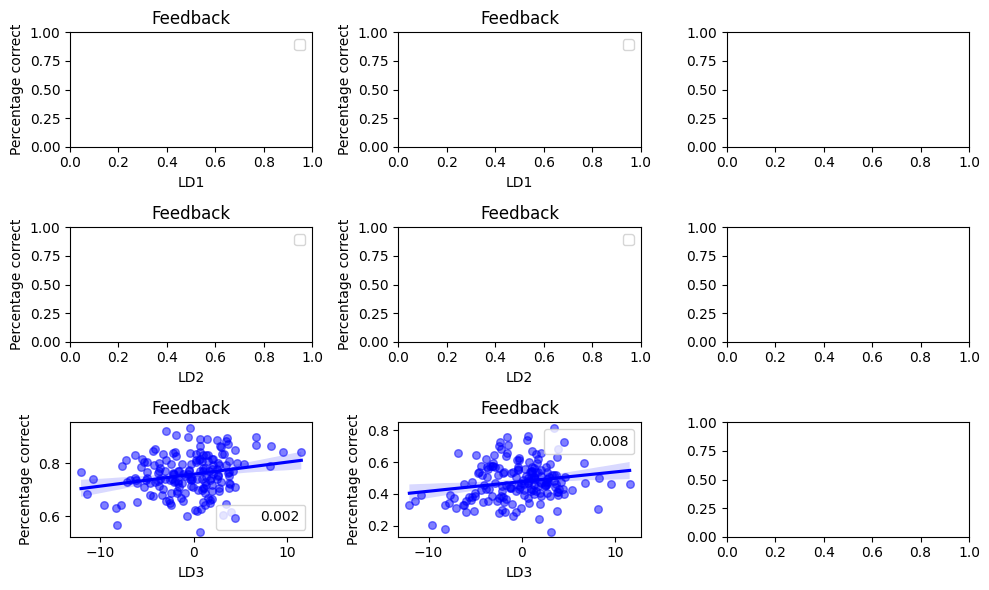

In [280]:
vars_interest = ['correct', 'binary_choice'] #, 'reaction', 'elongation']

fig, axs = plt.subplots(3, 3, sharex=False, sharey=False, figsize=(10, 6))
palette = sns.color_palette('Set1', 4)
for l, ld in enumerate(['LD1', 'LD2', 'LD3']):
    for v, var in enumerate(vars_interest):
        states_file[var] = states_file[var].astype(float)
        group_cols = ['mouse_name', 'session']
        # Mean per group
        data = (states_file.groupby(group_cols)[var].mean().reset_index())
        joint = data.merge(lda_df, on=['session', 'mouse_name'])
        
        var_data = joint[var]
        ld_data = joint[ld]
        res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(var_data.astype(float)))
        if res[1] < 0.05:
            sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(var_data.astype(float)), 
                        ax=axs[l, v], ci=95, color='blue', label=str(np.round(res[1], 3)), 
                        scatter_kws=dict(alpha=0.5, s=30, color='blue'))

        axs[l, v].set_xlabel(ld)
        axs[l, v].set_ylabel('Percentage correct')
        axs[l, v].legend()
        axs[l, v].set_title('Feedback')

plt.tight_layout()

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/2375032643.py:25: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/2375032643.py:25: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/2375032643.py:25: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/2375032643.py:25: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called

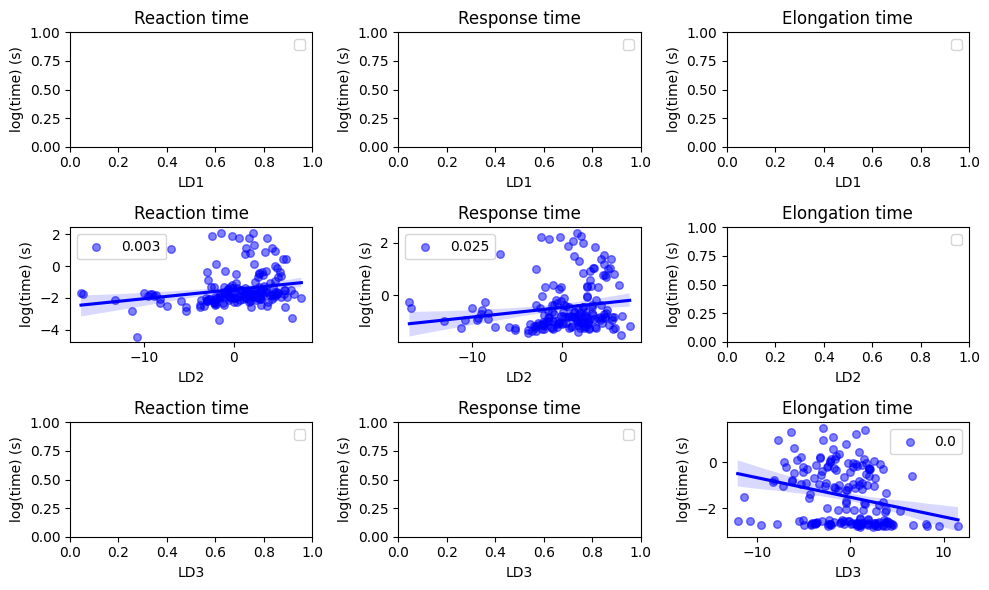

In [229]:
vars_interest = ['reaction', 'response', 'elongation']
titles = ['Reaction time', 'Response time', 'Elongation time']
fig, axs = plt.subplots(3, 3, sharex=False, sharey=False, figsize=(10, 6))
palette = sns.color_palette('Set1', 4)
for l, ld in enumerate(['LD1', 'LD2', 'LD3']):
    for v, var in enumerate(vars_interest):
        states_file[var] = states_file[var].astype(float)
        group_cols = ['mouse_name', 'session']
        # Mean per group
        data = (states_file.groupby(group_cols)[var].median().reset_index())
        joint = data.merge(lda_df, on=['session', 'mouse_name'])
        
        var_data = np.log(joint[var])
        # var_data = np.sqrt(joint[var])
        # var_data = joint[var]
        ld_data = joint[ld]
        res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(var_data.astype(float)))
        if res[1] < 0.05:
            sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(var_data.astype(float)), 
                        ax=axs[l, v], ci=95, color='blue', label=str(np.round(res[1], 3)), 
                        scatter_kws=dict(alpha=0.5, s=30, color='blue'))

        axs[l, v].set_xlabel(ld)
        axs[l, v].set_ylabel('log(time) (s)')
        axs[l, v].legend()
        axs[l, v].set_title(titles[v])

plt.tight_layout()

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/2631811224.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/2631811224.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/2631811224.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_24437/2631811224.py:29: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called

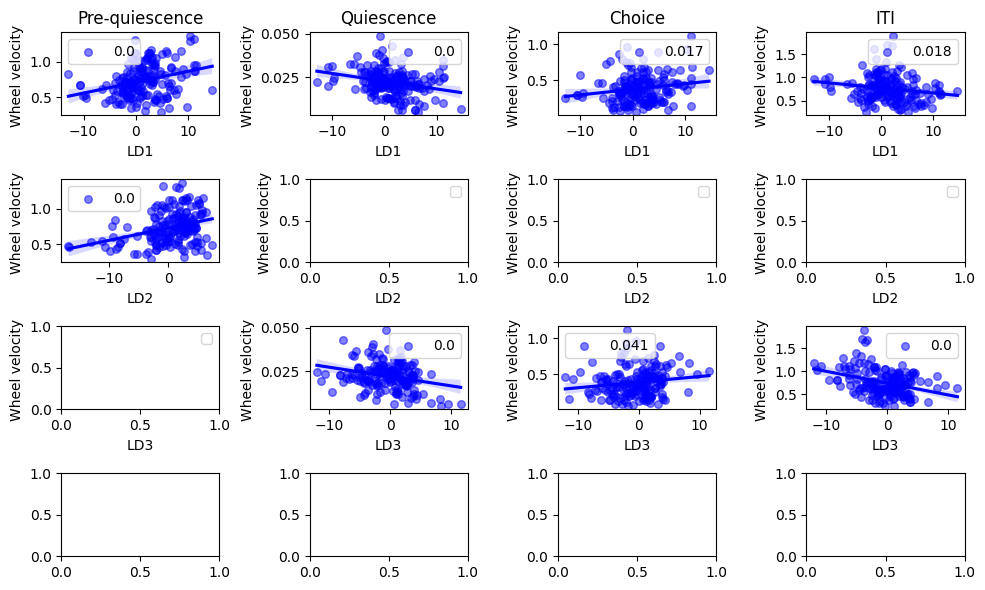

In [ ]:
var = 'abs_wheel_vel'
states_file['abs_wheel_vel'] = np.abs(states_file['avg_wheel_vel'])

fig, axs = plt.subplots(3, 4, sharex=False, sharey=False, figsize=(10, 6))
palette = sns.color_palette('Set1', 4)
for l, ld in enumerate(['LD1', 'LD2', 'LD3']):
    for e, epoch in enumerate(['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']):
        colors = ['blue', 'red']
        states_file[var] = states_file[var].astype(float)
        group_cols = ['mouse_name', 'session', 'broader_label']
        # Mean per group
        data = (states_file.groupby(group_cols)[var].mean().reset_index())
        joint = data.merge(lda_df, on=['session', 'mouse_name'])

        epoch_data = joint.loc[joint['broader_label']==epoch].dropna()

        var_data = -np.log(epoch_data[var])
        var_data = epoch_data[var]
        # paw_data = np.sqrt(epoch_data[paw])
        ld_data = epoch_data[ld]
        res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(var_data.astype(float)))
        if res[1] < 0.05:
            sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(var_data.astype(float)), 
                        ax=axs[l, e], ci=95, color=colors[0], label=str(np.round(res[1], 3)), 
                        scatter_kws=dict(alpha=0.5, s=30, color=colors[0]))

        axs[l, e].set_xlabel(ld)
        axs[l, e].set_ylabel('Wheel velocity ')
        axs[l, e].legend()

        axs[0, e].set_title(epoch)

plt.tight_layout()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


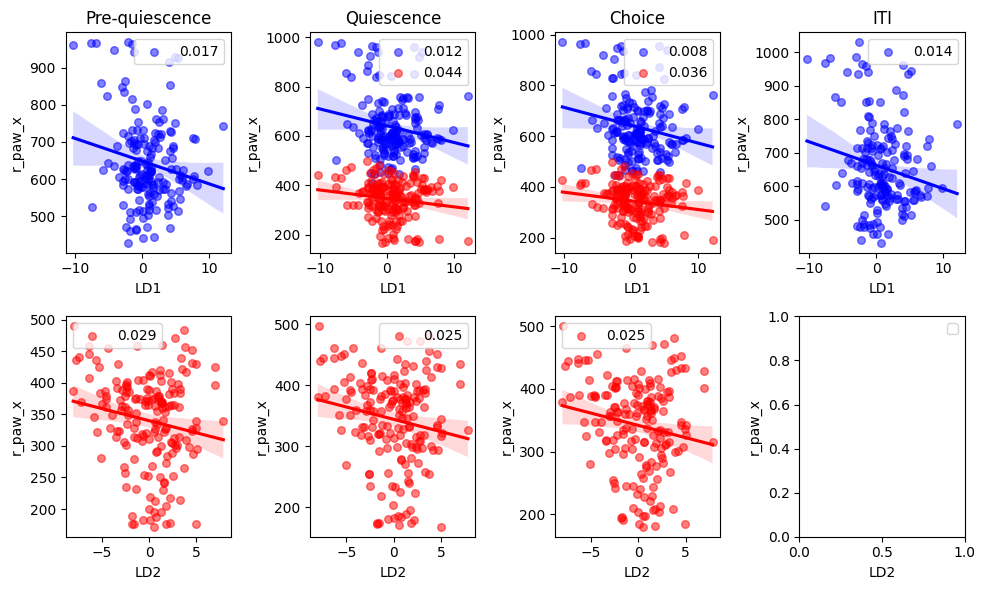

In [ ]:
var = 'abs_wheel_vel'
states_file['abs_wheel_vel'] = np.abs(states_file['avg_wheel_vel'])

fig, axs = plt.subplots(2, 4, sharex=False, sharey=False, figsize=(10, 6))
palette = sns.color_palette('Set1', 4)
for l, ld in enumerate(['LD1', 'LD2']):
    for e, epoch in enumerate(['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']):
        for v, var in enumerate(['l_paw_x', 'r_paw_x']):
            colors = ['blue', 'red']
            states_file[var] = states_file[var].astype(float)
            group_cols = ['mouse_name', 'session', 'broader_label']
            # Mean per group
            data = (states_file.groupby(group_cols)[var].mean().reset_index())
            joint = data.merge(lda_df, on=['session', 'mouse_name'])

            epoch_data = joint.loc[joint['broader_label']==epoch].dropna()

            # var_data = -np.log(epoch_data[var])
            var_data = epoch_data[var]
            # paw_data = np.sqrt(epoch_data[paw])
            ld_data = epoch_data[ld]
            res = stats.pearsonr(np.array(ld_data.astype(float)), np.array(var_data.astype(float)))
            if res[1] < 0.05:
                sns.regplot(x=np.array(ld_data.astype(float)), y=np.array(var_data.astype(float)), 
                            ax=axs[l, e], ci=95, color=colors[v], label=str(np.round(res[1], 3)), 
                            scatter_kws=dict(alpha=0.5, s=30, color=colors[v]))

            axs[l, e].set_xlabel(ld)
            axs[l, e].set_ylabel(var)
            axs[l, e].legend()

            axs[0, e].set_title(epoch)

plt.tight_layout()

# Plot correlations per epoch and state

In [ ]:
use_lda = clustered.copy()
use_lda['session'] = np.array(session_syllables.reset_index()['session'])
use_lda = use_lda.sort_values(by=['session'])


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_26183/2420400624.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  use_data['syllable'] = rename_func(use_data['syllable'])
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anacond

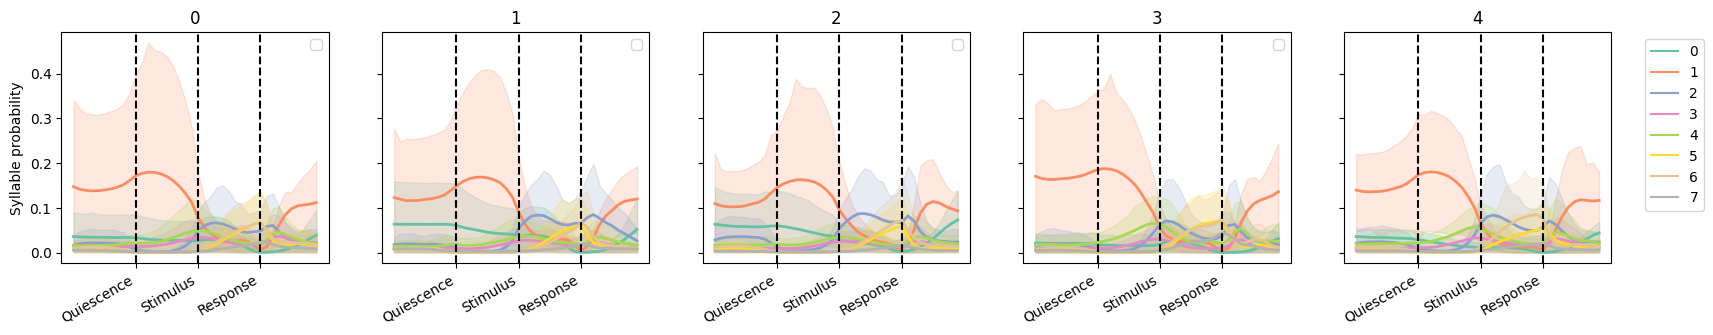

In [ ]:
syllable_labels = ['000', '100', '200', '300', '400', '500', '600', '700',
                   '010', '110', '210', '310', '410', '510', '610', '710',
                   '001', '101', '201', '301', '401', '501', '601', '701',
                   '011', '111', '211', '311', '411', '511', '611', '711']

palette_7 = create_grouped_gradient_palette(n_groups=8, shades_per_group=1, base_palette='Set2')
palette_7_list = [palette_7(i) for i in range(palette_7.N)]  # Extract colors properly


fig, axs = plt.subplots(1, 5, sharex=True, sharey=True, figsize=(20, 3))

for c, cluster in enumerate(np.unique(clusters)):
    use_data = reshaped_probs.loc[reshaped_probs['cluster']==cluster]
    use_data['syllable'] = rename_func(use_data['syllable'])
    use_data = use_data.copy()
    sns.lineplot(x='timestep', y='prob', hue='syllable', data=use_data, 
                ax=axs[c], palette='Set2',  linewidth=2)  #  legend=labels[c]  style=var_interest,

    axs[c].axvline(x=10, color='k', linestyle='--')
    axs[c].axvline(x=20, color='k', linestyle='--')
    axs[c].axvline(x=30, color='k', linestyle='--')
    axs[c].set_ylabel('Syllable probability')
    axs[c].set_xlabel('')
    # axs[c].set_ylim([0, 0.85])
    axs[c].set_xticks(np.arange(10, 31, 10), ['Quiescence', 'Stimulus', 'Response'], rotation=30, ha='right')
    axs[c].legend('')
    axs[c].set_title(cluster)
axs[c].legend(loc='upper left', bbox_to_anchor=(1.1, 1))

In [ ]:
order = ['000', '010', '001', '011', '100', '110', '101', '111', '200', '210', '201', '211',
         '300', '310', '301', '311', '400', '410',  '401', '411',
         '500', '510', '501', '511', '600', '610', '601', '611',
         '700', '710', '701', '711']
labels = ['No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick',  
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick', 
          'No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick']

rename_labels = dict(zip(np.array(order), np.array(labels)))
rename_func = np.vectorize(rename_labels.get)

# Syllable corr per timestep

In [168]:
identifiable_mapping = {'000': 0.0,
        '100': 1.0,
        '200': 2.0,
        '300': 3.0,
        '400': 4.0,
        '500': 5.0,
        '600': 6.0,
        '700': 7.0,
        
        '010': 8.0,
        '110': 9.0,
        '210': 10.0,
        '310': 11.0,
        '410': 12.0,
        '510': 13.0,
        '610': 14.0,
        '710': 15.0,

        '001': 16.0,
        '101': 17.0,
        '201': 18.0,
        '301': 19.0, 
        '401': 20.0, 
        '501': 21.0, 
        '601': 22.0, 
        '701': 23.0, 

        '011': 24.0,
        '111': 25.0,
        '211': 26.0,
        '311': 27.0,
        '411': 28.0,
        '511': 29.0,
        '611': 30.0,
        '711': 31.0,
        'nan': np.nan
        }

inverted_mapping = {v: k for k, v in identifiable_mapping.items()}
inverted_func = np.vectorize(inverted_mapping.get)
identifiable_func = np.vectorize(identifiable_mapping.get)
    
from matplotlib.colors import ListedColormap, to_rgb, to_hex

def create_grouped_gradient_palette(n_groups=8, shades_per_group=4, base_palette='Set1'):
    # Pick n_groups distinct colors from base palette
    base_colors = sns.color_palette(base_palette, n_colors=n_groups)
    
    # Function to generate shades for a given color
    def generate_shades(color, n_shades):
        color_rgb = np.array(to_rgb(color))
        # Create shades by interpolating towards white (lighter) or black (darker)
        factors = np.linspace(0.4, 1.0, n_shades)  # You can adjust range for more/less contrast
        return [to_hex(color_rgb * factor + (1 - factor)) for factor in factors]
    
    # Build full palette
    full_palette = []
    for color in base_colors:
        shades = generate_shades(color, shades_per_group)
        full_palette.extend(shades)
    
    return ListedColormap(full_palette)

palette_16 = create_grouped_gradient_palette(n_groups=8, shades_per_group=4, base_palette='Set2')

identifiable_mapping = {'000': 0.0,
        '100': 4.0,
        '200': 8.0,
        '300': 12.0,
        '400': 16.0,
        '500': 20.0,
        '600': 24.0,
        '700': 28.0,
        
        '010': 1.0,
        '110': 5.0,
        '210': 9.0,
        '310': 13.0,
        '410': 17.0,
        '510': 21.0,
        '610': 25.0,
        '710': 29.0,

        '001': 2.0,
        '101': 6.0,
        '201': 10.0,
        '301': 14.0, 
        '401': 18.0, 
        '501': 22.0, 
        '601': 26.0, 
        '701': 30.0, 

        '011': 3.0,
        '111': 7.0,
        '211': 11.0,
        '311': 15.0,
        '411': 19.0,
        '511': 23.0,
        '611': 27.0,
        '711': 31.0,
        'nan': np.nan
        }

# inverted_mapping = {v: k for k, v in identifiable_mapping.items()}
inverted_func = np.vectorize(inverted_mapping.get)
identifiable_func = np.vectorize(identifiable_mapping.get)

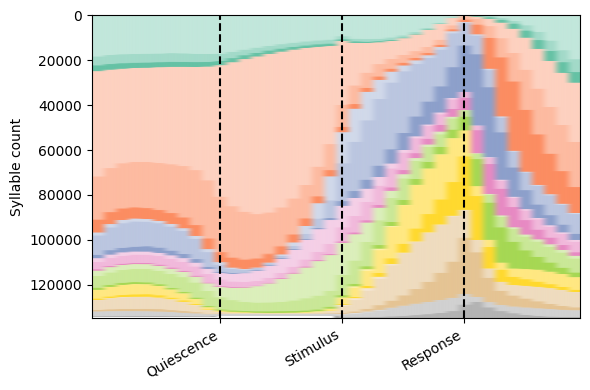

In [169]:
fig, axs = plt.subplots(1, 1, sharex=True, sharey=False, figsize=(6, 4))

epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']

mouse_data = all_sequences.copy()
bound = int(np.shape(mouse_data)[0]/4)
mouse_seq = np.ones((bound, 40)) * np.nan
all_epochs = []
for e, epoch in enumerate(epoch_to_analyse):
    epoch_data = np.vstack(mouse_data.loc[mouse_data['broader_label']==epoch, 'binned_sequence'].values)[:bound, :]
    epoch_data = inverted_func(epoch_data)
    # epoch_data = rename_func(epoch_data)
    epoch_data = identifiable_func(epoch_data)
    mouse_seq[:np.shape(epoch_data)[0], 10*e:10*e+10] = epoch_data[:np.shape(epoch_data)[0], :]
    # if e == 0:
    #     all_epochs = epoch_data[:bound-10, :]
    # else:
    #     all_epochs = np.concatenate([all_epochs, epoch_data[:bound-10, :]], axis=1)
# sorted = all_epochs[np.argsort([ordered_dict[row[0]] for row in all_epochs])]
axs.imshow(np.sort(mouse_seq, axis=0), aspect='auto', cmap=palette_16, interpolation=None, alpha=1)
axs.axvline(x=10, color='k', linestyle='--')
axs.axvline(x=20, color='k', linestyle='--')
axs.axvline(x=30, color='k', linestyle='--')
axs.set_ylabel('Syllable count')
axs.set_xlabel('')
axs.set_title('')
axs.set_xticks(np.arange(10, 31, 10), ['Quiescence', 'Stimulus', 'Response'], rotation=30, ha='right')
plt.tight_layout()
# axs[m].set_yticks('')
# plt.show()

## Per syllable x epoch 
- no trial type
- for clustering of mice

In [219]:
n_ld = 6
n_syllables = 32*4


In [237]:
group_cols = ['mouse_name', 'session', 'broader_label']
# group_cols = ['mouse_name', 'broader_label']

# Count syllables per group
data = (
    syllable_df
    .groupby(group_cols + ['most_likely_states'])
    .size()
    .reset_index(name='count'))

# Convert counts to fractions within each group
data['usage'] = (
    data['count'] /
    data.groupby(group_cols)['count'].transform('sum'))

group_cols = ['mouse_name', 'session']
# group_cols = ['mouse_name']
data = pd.pivot_table(data, values='usage', index=group_cols, columns=['most_likely_states', 'broader_label']).reset_index().fillna(0)



In [238]:
df = pd.DataFrame(np.array(data.drop(columns=['mouse_name', 'session'])))
df['mouse_name'] = data['mouse_name']
df['session'] = data['session']

/tmp/ipykernel_9458/2165378409.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



In [239]:
df = pd.DataFrame(np.array(data.drop(columns='mouse_name')))
df['mouse_name'] = data['mouse_name']

avg_lda = clustered.groupby(['mouse_name', 'lab', 'lab_number', 'litter_id', 'litter_number', 'mouse_cluster'])[np.arange(0, n_ld, 1)].mean().reset_index()
# avg_lda = avg_lda.rename(columns={0:'LD1', 1:'LD2', 2:'LD3', 3:'LD4', 4:'LD5', 5:'LD6'})
use_mice = avg_lda.mouse_name.unique()
df = df.loc[df['mouse_name'].isin(use_mice)]


/tmp/ipykernel_9458/2358175265.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



In [240]:
n_ld = 6
C = np.zeros((n_ld, n_syllables))
for k in range(n_ld):
    C[k] = [
        stats.pearsonr(df[s], avg_lda[k])[0]
        for s in range(n_syllables)
    ]

sns.heatmap(C, center=0, cmap='coolwarm')
plt.ylabel('LDA component')
plt.xlabel('Syllable')


ValueError: `x` and `y` must have the same length along `axis`.

In [234]:
# avg_lda = clustered.groupby(['mouse_name', 'lab', 'lab_number', 'litter_id', 'litter_number', 'mouse_cluster'])[np.arange(0, n_ld, 1)].mean().reset_index()
use_lda = clustered.copy()
use_lda['session'] = np.array(session_syllables.reset_index()['session'])
use_lda = use_lda.sort_values(by=['session'])

use_mice = use_lda.mouse_name.unique()
df = df.loc[df['mouse_name'].isin(use_mice)]
df = df.sort_values(by=['session'])


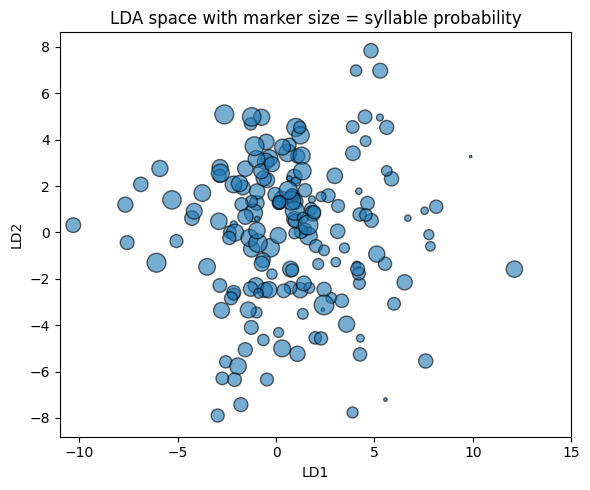

In [223]:

# rescale probabilities → marker sizes
p = np.array(df[0])
sizes = 0 + 200 * (p - p.min()) / (p.max() - p.min())

plt.figure(figsize=(6,5))

plt.scatter(
    use_lda[0],
    use_lda[1],
    s=sizes,
    alpha=0.6,
    edgecolor='k'
)

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA space with marker size = syllable probability')
plt.xlim([-11, 15])
plt.tight_layout()
plt.show()


In [114]:
from scipy import stats

IndexError: index 3 is out of bounds for axis 0 with size 3

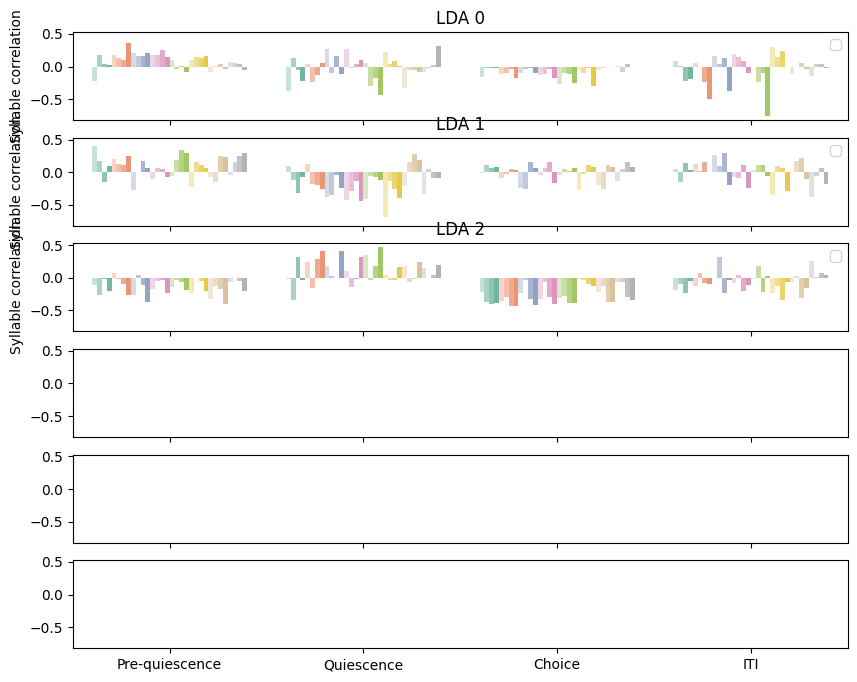

In [212]:
palette_16 = create_grouped_gradient_palette(n_groups=8, shades_per_group=4, base_palette='Set2')

palette_16_list = [palette_16(i) for i in range(palette_16.N)]  # Extract colors properly

fig, axs = plt.subplots(6, 1, sharex=True, sharey=True, figsize=(10, 8))

for l in range(6):
    C_df = pd.DataFrame(C[l, :])
    C_df['syllable_name'] = ['000', '100', '200', '300', '400', '500', '600', '700', '010', '110',
                                '210', '310', '410', '510', '610', '710', '001', '101', '201', '301', '401', '501', '601', '701', '011',
                                '111', '211', '311', '411', '511',  '611',  '711']*4
    C_df['epoch'] = np.concatenate([np.zeros(32), np.zeros(32)+1, np.zeros(32)+2, np.zeros(32)+3])

    sns.barplot(x='epoch', y=use_lda, hue='syllable_name', data=C_df, palette=palette_16_list, ax=axs[l])
    axs[l].set_ylabel('Syllable correlation')
    axs[l].set_xlabel('')
    axs[l].set_title('LDA '+str(l))
    axs[l].set_xticks([0, 1, 2, 3], ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI'], rotation=30, ha='right')
    axs[l].legend('')
axs[2].legend(loc='upper left', bbox_to_anchor=(1.1, 3.5))

plt.tight_layout()

/tmp/ipykernel_9458/3890619626.py:40: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



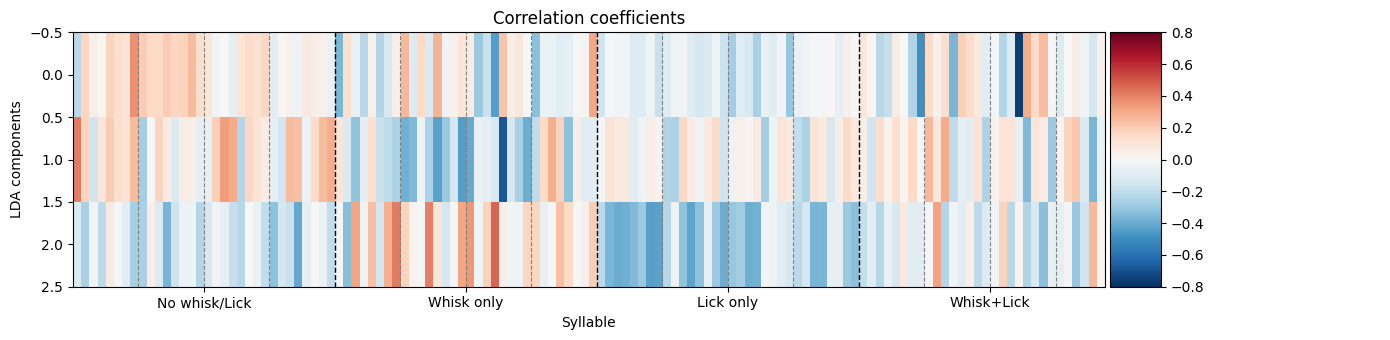

In [121]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

syllable_labels = ['000', '100', '200', '300', '400', '500', '600', '700',
                   '010', '110', '210', '310', '410', '510', '610', '710',
                   '001', '101', '201', '301', '401', '501', '601', '701',
                   '011', '111', '211', '311', '411', '511', '611', '711']
# plot weights for phase and individual identity
fig, ax = plt.subplots()
fig.set_size_inches(14,3.5)

plt_coefs = np.array(C)[:, :-2].astype(float)
plt.imshow(plt_coefs, cmap='RdBu_r', vmin=-.8, vmax=.8, aspect='auto')
plt.title('Correlation coefficients')
ax = plt.gca()
# plt.axhline(np.where(np.diff(mouse_coefs['mouse_cluster'])==1)[0][4] - 0.5+1, c='k', ls='--', lw=1)
plt.axvline(32-0.5, c='k', ls='--', lw=1)
plt.axvline(32*2 - 0.5, c='k', ls='--', lw=1)
plt.axvline(32*3 - 0.5, c='k', ls='--', lw=1)

plt.axvline(8-0.5, c='grey', ls='--', lw=.8)
plt.axvline(8*2 - 0.5, c='grey', ls='--', lw=.8)
plt.axvline(8*3 - 0.5, c='grey', ls='--', lw=.8)
plt.axvline(32+8-0.5, c='grey', ls='--', lw=.8)
plt.axvline(32+8*2 - 0.5, c='grey', ls='--', lw=.8)
plt.axvline(32+8*3 - 0.5, c='grey', ls='--', lw=.8)
plt.axvline((32*2)+8-0.5, c='grey', ls='--', lw=.8)
plt.axvline((32*2)+8*2 - 0.5, c='grey', ls='--', lw=.8)
plt.axvline((32*2)+8*3 - 0.5, c='grey', ls='--', lw=.8)
plt.axvline((32*3)+8-0.5, c='grey', ls='--', lw=.8)
plt.axvline((32*3)+8*2 - 0.5, c='grey', ls='--', lw=.8)
plt.axvline((32*3)+8*3 - 0.5, c='grey', ls='--', lw=.8)
# plt.xlim(-1.5, mouse_coefs.shape[1] - 0.5)
# plt.xticks(np.arange(0, 32*4, 1), syllable_labels*4)
plt.xticks(np.arange(16, 16*8, 32)-0.5, ['No whisk/Lick', 'Whisk only', 'Lick only', 'Whisk+Lick'])

# plt.xticks(np.arange(8, 47, 5), np.arange(0, 39, 5))
# plt.yticks(np.arange(0, len(mouse_coefs), 1), mouse_coefs['mouse_name'])
plt.xlabel('Syllable')
plt.ylabel('LDA components')
plt.legend(frameon=False, loc='upper left', bbox_to_anchor=(1.25, 1))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(cax=cax)
plt.tight_layout()

In [79]:
mouse_means = avg_lda.merge(df, on='mouse_name')
syllable_cols = np.arange(0, n_syllables, 1)
mouse_corrs = mouse_means[syllable_cols].corrwith(mouse_means[['LD1']])